In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'date').is_dir() and (p / 'images').is_dir()
)
DATA_DIR = PROJECT_ROOT / 'date'
IMAGES_DIR = PROJECT_ROOT / 'images'

sns.set_theme(style="whitegrid",font_scale = 1.2)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

由于数据集中无消费金额,只用R(最近一次消费)和F(消费频率)两个维度对用户进行分组

In [2]:
df = pd.read_parquet(DATA_DIR / 'user_behavior_cleaned_dataset.parquet')

In [3]:
buy_df = df[df['behavior_type'] == 'buy'].copy()
df_F = buy_df.groupby('user_id').size()
print(df_F)

user_id
100         8
117        10
119         3
121         1
122         3
           ..
1017960     3
1017965     1
1017972     4
1017997     2
1018011     1
Length: 7000, dtype: int64


In [4]:
df_date_deadline = buy_df.groupby('user_id')['date'].max()
all_deadline = pd.to_datetime('2017-12-03')
df_R = (all_deadline - df_date_deadline).dt.days
print(df_R)

user_id
100        5
117        5
119        4
121        8
122        1
          ..
1017960    0
1017965    6
1017972    4
1017997    2
1018011    7
Name: date, Length: 7000, dtype: int64


In [5]:
df_result = df_F.to_frame('F').join(df_R.to_frame('R')).reset_index().rename(columns={'index':'user_id'})
print(df_result)

      user_id   F  R
0         100   8  5
1         117  10  5
2         119   3  4
3         121   1  8
4         122   3  1
...       ...  .. ..
6995  1017960   3  0
6996  1017965   1  6
6997  1017972   4  4
6998  1017997   2  2
6999  1018011   1  7

[7000 rows x 3 columns]


In [6]:
bins_r = [-1,0,2,4,6,100]
labels_r = [5,4,3,2,1]
df_result['r_score'] = pd.cut(df_result['R'], bins=bins_r, labels=labels_r)
df_result['F_pct'] = df_result['F'].rank(pct=True,method='first')
bins_f = [0,0.2,0.4,0.6,0.8,1]
labels_f = [1,2,3,4,5]
df_result['f_score'] = pd.cut(df_result['F_pct'], bins=bins_f, labels=labels_f)
df_result = df_result.dropna(subset=['r_score'])
df_result['all_score'] = df_result['f_score'].astype(int) + df_result['r_score'].astype(int)
print(df_result)


      user_id   F  R r_score     F_pct f_score  all_score
0         100   8  5       2  0.941714       5          7
1         117  10  5       2  0.967286       5          7
2         119   3  4       3  0.572571       3          6
3         121   1  8       1  0.000143       1          2
4         122   3  1       4  0.572714       3          7
...       ...  .. ..     ...       ...     ...        ...
6995  1017960   3  0       5  0.728857       4          9
6996  1017965   1  6       2  0.337143       2          4
6997  1017972   4  4       3  0.820571       5          8
6998  1017997   2  2       4  0.572429       3          7
6999  1018011   1  7       1  0.337286       2          3

[7000 rows x 7 columns]


In [7]:
# 检查 r_score 和 f_score 的缺失值数量
print(df_result[['r_score', 'f_score']].isna().sum())

# 查看是否有任何一行的 r_score 或 f_score 为 NaN
print(df_result[df_result['r_score'].isna() | df_result['f_score'].isna()])

r_score    0
f_score    0
dtype: int64
Empty DataFrame
Columns: [user_id, F, R, r_score, F_pct, f_score, all_score]
Index: []


In [8]:
# 先将 r_score 和 f_score 转为整数
df_result['r_score'] = df_result['r_score'].astype(int)
df_result['f_score'] = df_result['f_score'].astype(int)

# 然后再计算中位数
r_median = df_result['r_score'].median()
f_median = df_result['f_score'].median()
print(f"R 中位数: {r_median}, F 中位数: {f_median}")

R 中位数: 4.0, F 中位数: 3.0


定义用户分层

In [9]:
# 定义分层函数
def rfm_segment(row):
    if row['r_score'] >= r_median and row['f_score'] >= f_median:
        return '高价值用户'
    elif row['r_score'] < r_median and row['f_score'] >= f_median:
        return '重点挽留用户'
    elif row['r_score'] >= r_median and row['f_score'] < f_median:
        return '潜力/新用户'
    else:
        return '流失用户'

# 应用函数，生成标签列
df_result['segment'] = df_result.apply(rfm_segment, axis=1)

# 查看分层结果
print(df_result['segment'].value_counts())
print(f"未购买用户: {df['user_id'].nunique() - df_result['user_id'].nunique()}")

segment
高价值用户     2825
流失用户      1580
重点挽留用户    1375
潜力/新用户    1220
Name: count, dtype: int64
未购买用户: 3202


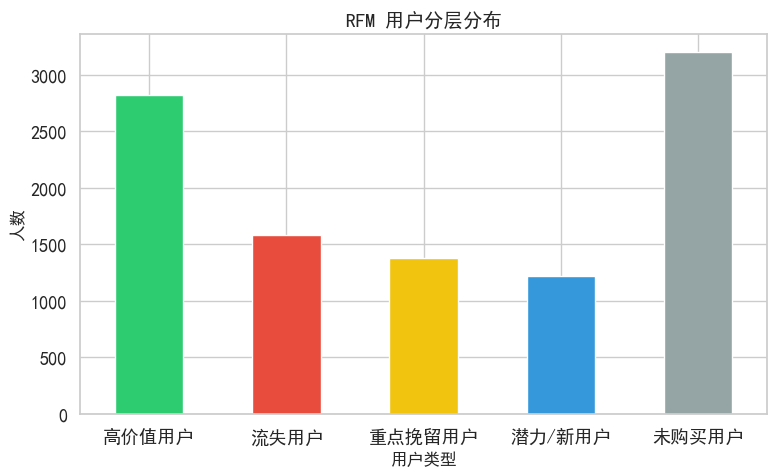

In [10]:
# 按分层统计人数
segment_counts = df_result['segment'].value_counts()
segment_counts.loc['未购买用户'] = df['user_id'].nunique() - df_result['user_id'].nunique()

# 绘制柱状图
plt.figure(figsize=(8, 5))
colors = {
    '高价值用户': '#2ecc71',
    '重点挽留用户': '#f1c40f',
    '潜力/新用户': '#3498db',
    '流失用户': '#e74c3c',
    '未购买用户': '#95a5a6'
}
segment_counts.plot(kind='bar', color=[colors[label] for label in segment_counts.index])
plt.title('RFM 用户分层分布', fontsize=14)
plt.xlabel('用户类型', fontsize=12)
plt.ylabel('人数', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'rfm_segment_distribution.png', dpi=300)
plt.show()